In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
col_names = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]

df = pd.read_csv(url, header=None, names=col_names, na_values="?")
df = df.dropna()  # remove missing values
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)  # converting to binary
print(df.head())


    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [43]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


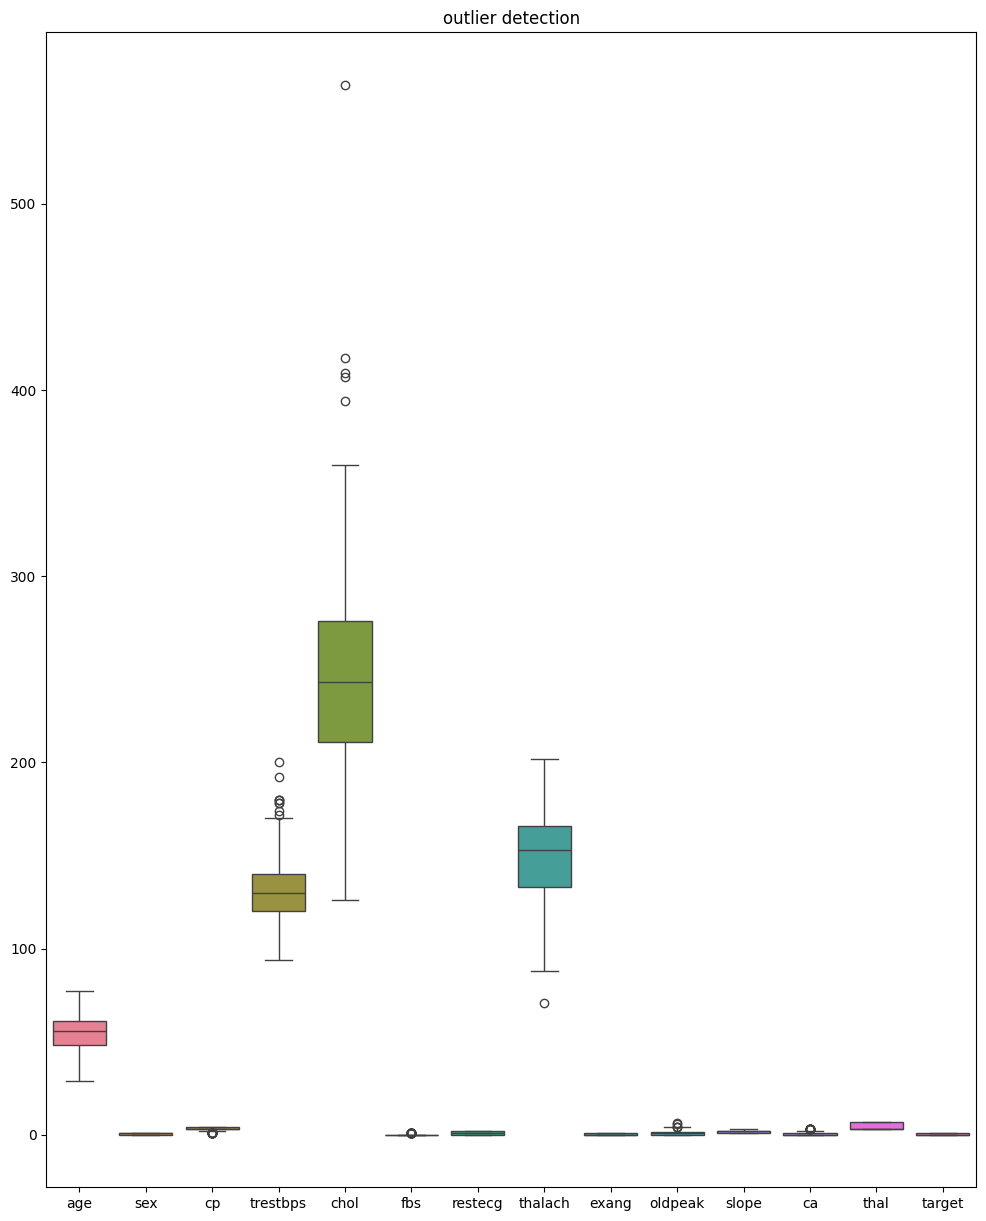

In [44]:
plt.figure(figsize=(12,15))
sns.boxplot(df.select_dtypes(include=np.number))
plt.title("outlier detection")
plt.show()

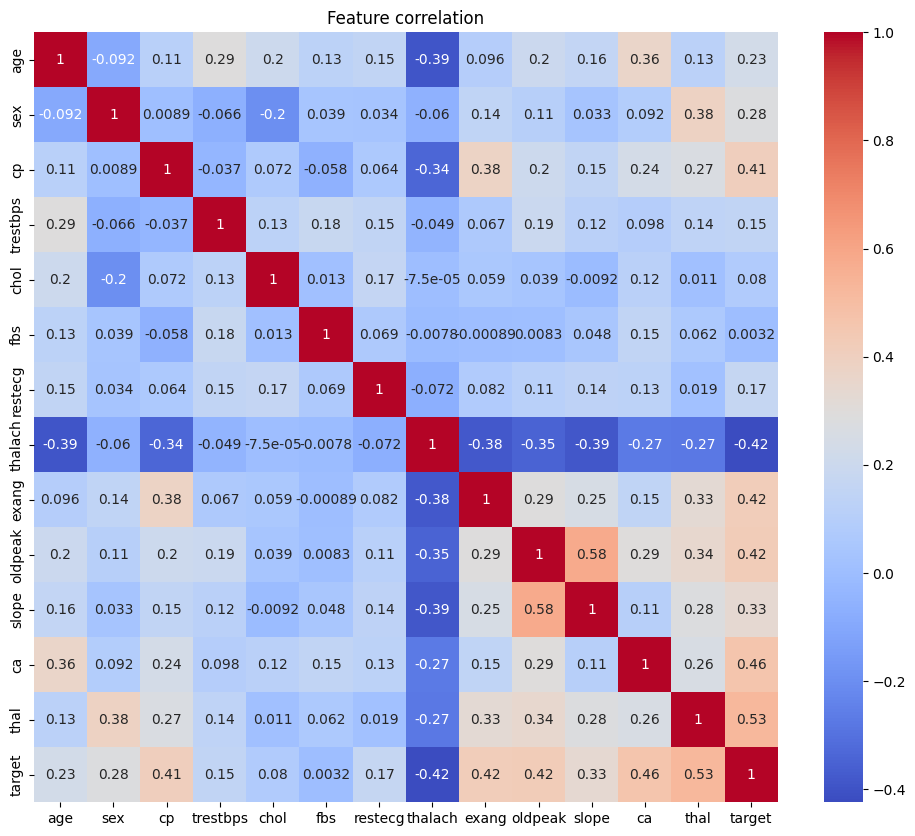

In [45]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

In [46]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['target'])
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(x_train, y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.8649789029535865
Testing Accuracy: 0.8333333333333334


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_1= LogisticRegression(penalty='l2', solver='liblinear')
model_1.fit(x_train, y_train)
y_train_pred = model_1.predict(x_train)
y_test_pred = model_1.predict(x_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8649789029535865
Testing Accuracy: 0.8333333333333334


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_2 = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5
)
model_2.fit(x_train, y_train)
y_train_pred = model_2.predict(x_train)
y_test_pred = model_2.predict(x_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.7130801687763713
Testing Accuracy: 0.7166666666666667


c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



**Comparison of Training and Testing Accuracy**

* **L1 (liblinear)**: Training Accuracy = 0.86, Testing Accuracy = 0.83
* **L2 (liblinear)**: Training Accuracy = 0.86, Testing Accuracy = 0.83
* **ElasticNet (saga, l1_ratio=0.5)**: Training Accuracy = 0.71, Testing Accuracy = 071

Observation: L1 and L2 penalties give similar performance. ElasticNet, which combines both L1 and L2, has slightly lower accuracy here but can be useful for balancing feature selection and regularization.

**Errors Encountered**

* Using L1 penalty with `lbfgs` solver resulted in the error:
  *“Solver lbfgs supports only 'l2' or None penalties, got l1 penalty.”*
  This is because L1 is only supported with `liblinear` (binary classification) or `saga`.

* Using ElasticNet without specifying `l1_ratio` resulted in the error:
  *“l1_ratio must be provided for elasticnet penalty.”*
  ElasticNet requires `l1_ratio` to balance L1 and L2 contributions.


**Parameters Changed and Their Relationship**

* **L1**: Changed solver to `liblinear` → selects sparse coefficients (some become zero).
* **L2**: No additional parameter change needed with `liblinear` or `lbfgs` → shrinks all coefficients smoothly.
* **ElasticNet**: Changed solver to `saga` and set `l1_ratio=0.5` → mix of L1 (sparse) and L2 (smooth shrinkage).

**Relationship:**

* The solver determines which penalties are allowed.
* L1 focuses on feature selection, L2 on coefficient shrinkage, and ElasticNet combines both, controlled by `l1_ratio`.


In [50]:
#Task 2:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

solvers = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
results = []

for solver in solvers:
    try:
        model = LogisticRegression(solver=solver, max_iter=500)
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        results.append({'Solver': solver, 'Training Accuracy': train_acc, 'Testing Accuracy': test_acc})
    except Exception as e:
        results.append({'Solver': solver, 'Training Accuracy': None, 'Testing Accuracy': None, 'Error': str(e)})
results_df = pd.DataFrame(results)
results_df



c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Solver,Training Accuracy,Testing Accuracy
0,lbfgs,0.961905,1.000000
1,liblinear,0.961905,0.977778
2,newton-cg,0.961905,1.000000
3,newton-cholesky,0.961905,1.000000
4,sag,0.971429,1.000000
5,saga,0.980952,1.000000


Effect of solver:
Solvers generally converge to similar accuracies for a small dataset like Iris.
Some solvers (like liblinear) are optimized for small datasets, while sag and saga are better for larger datasets.
lbfgs and newton-cg are good for multi-class problems and converge fast on medium datasets.
Solver recommendations by sklearn:
Small dataset: liblinear
Medium dataset: lbfgs, newton-cg
Large dataset: sag, saga
Best solver for Iris dataset:
Any solver works; lbfgs or newton-cg is convenient for multi-class and gives consistent results.

In [51]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]

heart_df = pd.read_csv(url, header=None, names=columns, na_values="?")
heart_df = heart_df.dropna()
heart_df["target"] = heart_df["target"].apply(lambda x: 1 if x > 0 else 0)
X_hd = heart_df.drop("target", axis=1)
y_hd = heart_df["target"]
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(X_hd, y_hd, test_size=0.3, random_state=42)
results_hd = []
for solver in solvers:
    try:
        model = LogisticRegression(solver=solver, max_iter=1000)
        model.fit(X_train_hd, y_train_hd)
        y_train_pred = model.predict(X_train_hd)
        y_test_pred = model.predict(X_test_hd)
        train_acc = accuracy_score(y_train_hd, y_train_pred)
        test_acc = accuracy_score(y_test_hd, y_test_pred)
        results_hd.append({'Solver': solver, 'Training Accuracy': train_acc, 'Testing Accuracy': test_acc})
    except Exception as e:
        results_hd.append({'Solver': solver, 'Training Accuracy': None, 'Testing Accuracy': None, 'Error': str(e)})
results_hd_df = pd.DataFrame(results_hd)
results_hd_df



c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\LAPTOOL TECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Solver,Training Accuracy,Testing Accuracy
0,lbfgs,0.840580,0.877778
1,liblinear,0.845411,0.877778
2,newton-cg,0.840580,0.877778
3,newton-cholesky,0.840580,0.877778
4,sag,0.816425,0.888889
5,saga,0.792271,0.855556


Step 5: Observations (Heart Disease)
Accuracy differences between solvers may appear slightly larger because Heart Disease dataset is bigger than Iris and has binary classification.
liblinear still works well for small datasets.
sag and saga show faster convergence for medium-sized datasets.
Dataset size affects solver efficiency, but final accuracy differences are generally minor for clean, structured datasets.

In [56]:
#Task 3:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

encoder = OneHotEncoder(sparse_output=False)
y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_one_hot = encoder.transform(y_test.reshape(-1, 1))
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(10, activation='relu'),
    Dense(y_train_one_hot.shape[1], activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(
    X_train_scaled, y_train_one_hot,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=0 # Suppress verbose output during training
)

print("Training complete.")
loss, accuracy = model.evaluate(X_test_scaled, y_test_one_hot, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

y_pred_one_hot = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_one_hot, axis=1)

report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:")
print(report)

ModuleNotFoundError: No module named 'tensorflow'

In [57]:
#Task 4:
import pandas as pd
import numpy as np

# Generate synthetic data for fraud detection
np.random.seed(42)
num_samples = 1000

data = {
    'transaction_id': np.arange(num_samples),
    'transaction_amount': np.random.uniform(10, 2000, num_samples).round(2),
    'customer_age': np.random.randint(18, 70, num_samples),
    'num_transactions_last_7_days': np.random.randint(1, 20, num_samples),
    'time_since_last_transaction': np.random.uniform(0.1, 24, num_samples).round(1),
    'location_risk_score': np.random.uniform(0, 1, num_samples).round(2),
    'is_fraud': np.random.choice([0, 1], num_samples, p=[0.95, 0.05]) # 5% fraud rate
}

df_fraud = pd.DataFrame(data)

# Introduce some patterns for 'fraud' cases
# For example, higher transaction amounts, lower age (maybe new accounts), higher location risk score
df_fraud.loc[df_fraud['is_fraud'] == 1, 'transaction_amount'] = np.random.uniform(500, 5000, df_fraud['is_fraud'].sum()).round(2)
df_fraud.loc[df_fraud['is_fraud'] == 1, 'customer_age'] = np.random.randint(18, 40, df_fraud['is_fraud'].sum())
df_fraud.loc[df_fraud['is_fraud'] == 1, 'location_risk_score'] = np.random.uniform(0.7, 1, df_fraud['is_fraud'].sum()).round(2)

# Save the synthetic dataset to a CSV file
df_fraud.to_csv('fraud_detection.csv', index=False)
print("Synthetic fraud_detection.csv created.")

# Load the dataset into a pandas DataFrame
df = pd.read_csv('fraud_detection.csv')

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

Synthetic fraud_detection.csv created.

First 5 rows of the DataFrame:
   transaction_id  transaction_amount  customer_age  \
0               0              755.33            64   
1               1             1901.92            29   
2               2             1466.67            33   
3               3             1201.33            41   
4               4              320.48            36   

   num_transactions_last_7_days  time_since_last_transaction  \
0                             8                         17.4   
1                             6                         12.8   
2                             8                         20.9   
3                            18                          3.2   
4                             3                         19.0   

   location_risk_score  is_fraud  
0                 0.70         0  
1                 0.84         0  
2                 0.80         0  
3                 0.96         0  
4                 0.54         0  


In [58]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   transaction_id  transaction_amount  customer_age  \
0               0              755.33            64   
1               1             1901.92            29   
2               2             1466.67            33   
3               3             1201.33            41   
4               4              320.48            36   

   num_transactions_last_7_days  time_since_last_transaction  \
0                             8                         17.4   
1                             6                         12.8   
2                             8                         20.9   
3                            18                          3.2   
4                             3                         19.0   

   location_risk_score  is_fraud  
0                 0.70         0  
1                 0.84         0  
2                 0.80         0  
3                 0.96         0  
4                 0.54         0  

DataFrame Info:
<class 'pandas.core.frame.

In [59]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(['transaction_id', 'is_fraud'], axis=1)
y = df['is_fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nClass distribution in y_train before SMOTE:")
print(y_train.value_counts())

Shape of X_train: (800, 5)
Shape of X_test: (200, 5)
Shape of y_train: (800,)
Shape of y_test: (200,)

Class distribution in y_train before SMOTE:
is_fraud
0    755
1     45
Name: count, dtype: int64


In [61]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])

Shape of X_train_scaled: (800, 5)
Shape of X_test_scaled: (200, 5)
First 5 rows of X_train_scaled:
 [[-0.63072534  0.51453751  0.90055688 -0.91872012  0.44077208]
 [-0.81418809 -0.02222534  1.43806908  0.03966025  1.52117857]
 [ 0.48317814 -1.36413245 -0.71197969 -1.7028495  -0.16695656]
 [-1.15421709  0.78291893  1.43806908  1.57887719 -0.33577008]
 [-1.39907889 -0.08932069  0.90055688 -1.52859853  0.20443316]]


In [60]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("\nClass distribution in y_train_resampled after SMOTE:")
print(y_train_resampled.value_counts())

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Get the number of features from the resampled training data
input_dim = X_train_resampled.shape[1]

# Initialize the Sequential model
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)), # Hidden Layer 1
    Dense(64, activation='tanh'),                            # Hidden Layer 2
    Dense(32, activation='relu'),                            # Hidden Layer 3
    Dense(1, activation='sigmoid')                           # Output Layer for binary classification
])

# Print the model summary
print(model.summary())

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Get the number of features from the resampled training data
input_dim = X_train_resampled.shape[1]

# Initialize the Sequential model
model = Sequential([
    Input(shape=(input_dim,)),                       # Explicit Input Layer to avoid UserWarning
    Dense(128, activation='relu'),                    # Hidden Layer 1
    Dense(64, activation='tanh'),                     # Hidden Layer 2
    Dense(32, activation='relu'),                     # Hidden Layer 3
    Dense(1, activation='sigmoid')                    # Output Layer for binary classification
])

# Print the model summary
print(model.summary())

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy, Precision, Recall
model.compile(
    optimizer=Adam(), 
    loss='binary_crossentropy', 
    metrics=[Accuracy(), Precision(), Recall()] 
)

print("Model compiled successfully with Adam optimizer, binary_crossentropy loss, and Accuracy, Precision, Recall metrics.")

In [ ]:
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1 # Display training progress
)

print("Model training complete.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the scaled test data
y_pred_proba = model.predict(X_test_scaled)

# Convert probabilities to binary class labels (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1 Score: {f1:.4f}")

In [ ]:
#Task 5:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy, Precision, Recall
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Generate synthetic data for fraud detection
np.random.seed(42)
num_samples = 1000

data = {
    'transaction_id': np.arange(num_samples),
    'transaction_amount': np.random.uniform(10, 2000, num_samples).round(2),
    'customer_age': np.random.randint(18, 70, num_samples),
    'num_transactions_last_7_days': np.random.randint(1, 20, num_samples),
    'time_since_last_transaction': np.random.uniform(0.1, 24, num_samples).round(1),
    'location_risk_score': np.random.uniform(0, 1, num_samples).round(2),
    'is_fraud': np.random.choice([0, 1], num_samples, p=[0.95, 0.05]) # 5% fraud rate
}

df_fraud = pd.DataFrame(data)

# Introduce some patterns for 'fraud' cases 
df_fraud.loc[df_fraud['is_fraud'] == 1, 'transaction_amount'] = np.random.uniform(500, 5000, df_fraud['is_fraud'].sum()).round(2)
df_fraud.loc[df_fraud['is_fraud'] == 1, 'customer_age'] = np.random.randint(18, 40, df_fraud['is_fraud'].sum())
df_fraud.loc[df_fraud['is_fraud'] == 1, 'location_risk_score'] = np.random.uniform(0.7, 1, df_fraud['is_fraud'].sum()).round(2)

# Save and load the synthetic dataset
df_fraud.to_csv('fraud_detection.csv', index=False)
df = pd.read_csv('fraud_detection.csv')

print("Synthetic fraud_detection.csv created and loaded.")
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

In [ ]:
# Separate features (X) and target (y)
X = df.drop(['transaction_id', 'is_fraud'], axis=1)
y = df['is_fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Class distribution in y_train before SMOTE:")
print(y_train.value_counts())
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler.")
# Address class imbalance using SMOTE on the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nTraining data resampled using SMOTE.")
print("Class distribution in y_train_resampled after SMOTE:")
print(y_train_resampled.value_counts())


In [ ]:
# Get the number of features for the input layer
input_dim = X_train_resampled.shape[1]
model = Sequential([
    Input(shape=(input_dim,)),                       
    Dense(128, activation='relu'),                    
    Dense(64, activation='tanh'),                    
    Dense(32, activation='relu'),                    
    Dense(1, activation='sigmoid')                   
])

print("MLP Model Architecture:")
print(model.summary())

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=[Accuracy(name='accuracy'), Precision(name='precision'), Recall(name='recall')]
)

print("\nModel compiled successfully.")

In [ ]:
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nModel training complete.")
# Make predictions on the scaled test data
y_pred_proba = model.predict(X_test_scaled)

# Convert probabilities to binary class labels (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1 Score: {f1:.4f}")